<a href="https://colab.research.google.com/github/isshhaanntt/netflix-subscriber-churn-prediction/blob/main/netflix_churn_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix subscriber churn — simple AI/ML model (Logistic Regression)

This notebook builds a **Logistic Regression** model to predict whether a subscriber will churn (cancel their subscription).

Logistic Regression is used here instead of a more complex model (like Random Forest) because it is:
- Easy to explain in class — every feature gets **one weight (coefficient)**
- Transparent — you can show the exact formula the model uses to make a prediction
- Still a real, working AI/ML classification model

**Note:** Netflix's real subscriber data is private, so this notebook uses a realistic *synthetic* dataset built with the same features described in the case study's "Data Required" slide.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 2. Create the synthetic subscriber dataset

Each row represents one subscriber. The features match the "Data Required" slide:
- `tenure_months` — how long they've been subscribed
- `weekly_watch_hours` — average hours streamed per week
- `logins_per_month` — how often they open the app
- `support_tickets` — number of support tickets in the last 90 days
- `payment_failures` — number of failed payments in the last 90 days
- `plan_tier` — Basic, Standard, or Premium

The `churn` label (1 = churned, 0 = stayed) is generated using simple business rules, so the model has real patterns to learn.

In [2]:
n = 3000

tenure_months = np.random.randint(0, 61, n)
weekly_watch_hours = np.round(np.random.exponential(scale=6, size=n), 1)
weekly_watch_hours = np.clip(weekly_watch_hours, 0, 30)
logins_per_month = np.random.poisson(lam=10, size=n)
support_tickets = np.random.poisson(lam=0.8, size=n)
payment_failures = np.random.poisson(lam=0.3, size=n)
plan_tier = np.random.choice(['Basic', 'Standard', 'Premium'], size=n, p=[0.3, 0.5, 0.2])

# Simple, explainable business rule for churn risk (this is what the model will learn to approximate)
risk_score = (
    0.6
    - 0.05 * tenure_months
    - 0.10 * weekly_watch_hours
    - 0.04 * logins_per_month
    + 0.30 * support_tickets
    + 0.80 * payment_failures
    + np.where(plan_tier == 'Basic', 0.2, np.where(plan_tier == 'Premium', -0.2, 0))
    + np.random.normal(0, 0.6, n)
)
churn_prob = 1 / (1 + np.exp(-risk_score))
churn = (churn_prob > 0.5).astype(int)

df = pd.DataFrame({
    'tenure_months': tenure_months,
    'weekly_watch_hours': weekly_watch_hours,
    'logins_per_month': logins_per_month,
    'support_tickets': support_tickets,
    'payment_failures': payment_failures,
    'plan_tier': plan_tier,
    'churn': churn
})

df.head(10)

,tenure_months,weekly_watch_hours,logins_per_month,support_tickets,payment_failures,plan_tier,churn
0,38,5.6,16,0,0,Basic,0
1,51,4.7,9,0,0,Standard,0
2,28,1.6,12,2,1,Basic,1
3,14,3.0,11,0,0,Standard,0
4,42,5.4,10,2,0,Standard,0
5,7,4.1,9,1,0,Basic,1
6,60,26.4,12,0,0,Standard,0
7,20,0.9,9,0,0,Premium,0
8,38,7.1,7,1,2,Premium,0
9,57,3.1,15,0,0,Basic,0


## 3. Quick look at the data

In [3]:
print("Dataset shape:", df.shape)
print()
print("Churn rate:", round(df['churn'].mean() * 100, 1), "%")
print()
df.describe()

Dataset shape: (3000, 7)

Churn rate: 14.5 %



,tenure_months,weekly_watch_hours,logins_per_month,support_tickets,payment_failures,churn
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,30.297667,5.844967,10.076667,0.806000,0.316333,0.145333
std,17.543555,5.726577,3.167565,0.905522,0.574204,0.352495
min,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,15.000000,1.700000,8.000000,0.000000,0.000000,0.000000
50%,31.000000,4.100000,10.000000,1.000000,0.000000,0.000000
75%,46.000000,8.100000,12.000000,1.000000,1.000000,0.000000
max,60.000000,30.000000,24.000000,5.000000,4.000000,1.000000


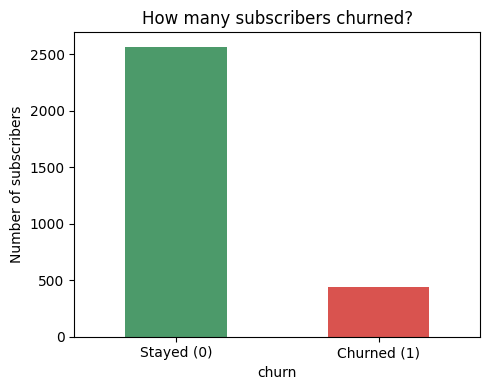

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
df['churn'].value_counts().sort_index().plot(kind='bar', color=['#4C9A6A', '#D9534F'], ax=ax)
ax.set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
ax.set_title('How many subscribers churned?')
ax.set_ylabel('Number of subscribers')
plt.tight_layout()
plt.show()

## 4. Prepare the data for the model

- Convert `plan_tier` (text) into numbers the model can use (one-hot encoding)
- Split into training data (80%) and test data (20%)
- Scale the numbers so no single feature dominates just because it has bigger numbers

In [5]:
df_model = pd.get_dummies(df, columns=['plan_tier'], drop_first=True)

X = df_model.drop('churn', axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Features used:", list(X.columns))

Training rows: 2400
Test rows: 600
Features used: ['tenure_months', 'weekly_watch_hours', 'logins_per_month', 'support_tickets', 'payment_failures', 'plan_tier_Premium', 'plan_tier_Standard']


## 5. Train the model

This is the actual AI/ML step. Logistic Regression finds one weight per feature that best separates churners from non-churners.

In [6]:
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained.")

Model trained.


## 6. Evaluate the model — how good are its predictions?

In [7]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 1), "%")
print()
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

Accuracy: 89.7 %

              precision    recall  f1-score   support

      Stayed       0.92      0.96      0.94       513
     Churned       0.69      0.53      0.60        87

    accuracy                           0.90       600
   macro avg       0.80      0.74      0.77       600
weighted avg       0.89      0.90      0.89       600



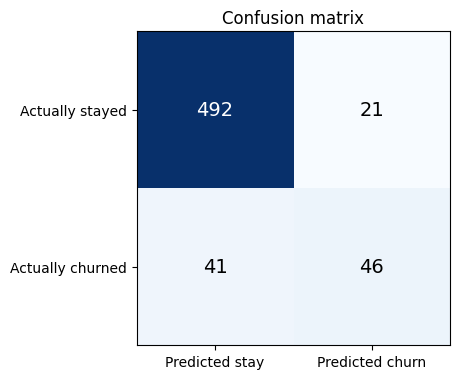

In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted stay', 'Predicted churn'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actually stayed', 'Actually churned'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

## 7. Why this feature matters — the model's weights

This is the easiest part to present in class. Each feature has **one coefficient**. A positive weight pushes a subscriber toward churn; a negative weight pushes them toward staying — and the size of the number shows how strong that effect is.

           feature    weight
     tenure_months -2.547421
weekly_watch_hours -1.821745
  payment_failures  1.344612
   support_tickets  0.814120
 plan_tier_Premium -0.571267
  logins_per_month -0.410776
plan_tier_Standard -0.399009


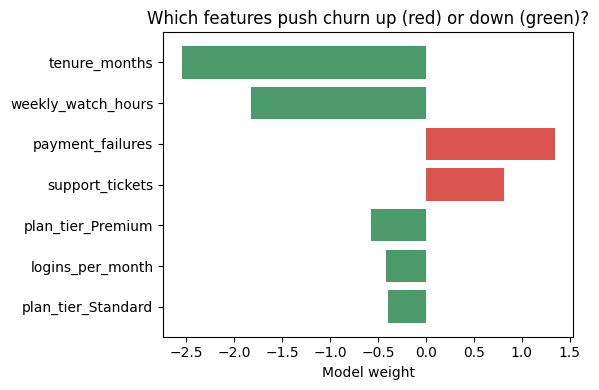

In [9]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'weight': model.coef_[0]
}).sort_values('weight', key=abs, ascending=False)

print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#D9534F' if w > 0 else '#4C9A6A' for w in coef_df['weight']]
ax.barh(coef_df['feature'], coef_df['weight'], color=colors)
ax.set_title('Which features push churn up (red) or down (green)?')
ax.set_xlabel('Model weight')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Try it live — predict churn for one subscriber

Change the numbers below to describe any subscriber and run the cell to see the model's prediction. This is a good moment to demo in class.

In [10]:
def predict_churn(tenure_months, weekly_watch_hours, logins_per_month,
                   support_tickets, payment_failures, plan_tier='Standard'):
    row = pd.DataFrame([{
        'tenure_months': tenure_months,
        'weekly_watch_hours': weekly_watch_hours,
        'logins_per_month': logins_per_month,
        'support_tickets': support_tickets,
        'payment_failures': payment_failures,
        'plan_tier_Premium': 1 if plan_tier == 'Premium' else 0,
        'plan_tier_Standard': 1 if plan_tier == 'Standard' else 0,
    }])
    row = row[X.columns]
    row_scaled = scaler.transform(row)
    prob = model.predict_proba(row_scaled)[0][1]
    print(f"Predicted churn probability: {prob * 100:.1f}%")
    print("Prediction:", "LIKELY TO CHURN" if prob > 0.5 else "LIKELY TO STAY")
    return prob

# Example: a subscriber with low tenure, low watch hours, and a couple of payment failures
predict_churn(tenure_months=3, weekly_watch_hours=1.5, logins_per_month=3,
              support_tickets=2, payment_failures=2, plan_tier='Basic')

Predicted churn probability: 100.0%
Prediction: LIKELY TO CHURN


np.float64(0.9995879459595404)

In [11]:
# Example: a loyal, highly engaged subscriber
predict_churn(tenure_months=36, weekly_watch_hours=12, logins_per_month=20,
              support_tickets=0, payment_failures=0, plan_tier='Premium')

Predicted churn probability: 0.0%
Prediction: LIKELY TO STAY


np.float64(2.7723891065013268e-05)

## Summary for the case study

- **Model type:** Logistic Regression (Classification)
- **Why this model:** it is easy to explain — every input feature has one clear weight, so you can show the class exactly how each factor pushes churn risk up or down
- **Top churn drivers found by the model:** payment failures and low engagement (watch hours, logins) increase churn risk; longer tenure and a Premium plan reduce it
- **Business action:** subscribers flagged as high-risk can be routed to the retention team for a discount offer, a free upgrade month, or proactive support outreach
- **Caveat:** trained on synthetic data built for this classroom exercise — a real deployment would use Netflix's actual subscriber data under proper privacy and governance controls